##Лабораторная работа №2. Исследование факторов и организация работы с таблицами данных



In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from google.colab import drive

drive.mount('/content/drive')
df = pd.read_excel('/content/drive/My Drive/Colab Notebooks/data_purch.xlsx')




Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
# Настройка стилей для графиков
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

# Загрузка и проверка данных
print("Данные успешно загружены.")
print(f"Размер исходного датасета: {df.shape}")
print("\nПервые 5 строк:")
print(df.head())
print("\nТипы данных:")
print(df.dtypes)
print("\nКоличество пропусков в каждом столбце:")
print(df.isnull().sum())



Данные успешно загружены.
Размер исходного датасета: (556312, 22)

Первые 5 строк:
  first_pub_date final_protocol_pub_date purchase_number  \
0     2021-03-30              2021-04-12       AA0000001   
1     2021-03-30              2021-04-12       AB0000002   
2     2021-05-24              2021-06-08       AD0000003   
3     2021-05-24              2021-06-08       AD0000003   
4     2021-05-24              2021-06-08       AD0000003   

  collecting_start_date collecting_end_date    placing_base_name  \
0            2021-03-30          2021-04-07  Электронный аукцион   
1            2021-03-30          2021-04-07  Электронный аукцион   
2            2021-05-24          2021-06-01  Электронный аукцион   
3            2021-05-24          2021-06-01  Электронный аукцион   
4            2021-05-24          2021-06-01  Электронный аукцион   

            cust_reg  lot_price_correct                     drug_mnn_ext_code  \
0  Республика Адыгея           56040.00  5d6d137c-75b7-11ea-b5ac-1

##Показатели, сильно влияющие на вероятность незакрытия покупки:

lot_price_correct: максимально возможная цена за все препараты в закупке, объявленная заказчиком.

drug_qty: объём закупаемого лекарственного препарата.

drug_price: цена за единицу объема закупаемого лекарственного препарата.

drug_position_price: цена за всю позицию закупаемого лекарственного препарата.

is_znvlp: содержится ли препарат в списке ЖВЛП?

is_narcotic – есть ли в составе наркотические вещества?

is_msp_purchase – предназначена ли закупка только для субъектов малого и среднего предпринимательства?

is_dif – есть ли в закупке хотя бы 1 препарат, являющийся дефицитным?

app_amount_absolute_correct – сумма залога.

advance_sum_correct – сумма аванса.

## Формирование новых факторов

Фактор, полученный с помощью метода главных компонент:

*   PCA - фактор полученный при помощи метода главных компонент по 1-ой компоненте.

Остальные факторы:


*   number_of_drugs - количество препаратов в закупке.
*   Сумма аванса и залога (advance_sum_correct + app_amount_absolute_correct).




In [20]:
# группируем данные по purchase_number

grouped_df = df.groupby('purchase_number').agg({
    'lot_price_correct': 'first',
    'drug_qty': 'sum',
    'drug_price': 'sum',
    'drug_position_price': 'sum',
    'is_abnd': 'first',
    'is_znvlp': 'first',
    'is_povt': 'first',
    'is_dif': 'first',
    'app_amount_absolute_correct': 'first',
    'advance_sum_correct': 'first'
})

grouped_df

,lot_price_correct,drug_qty,drug_price,drug_position_price,is_abnd,is_znvlp,is_povt,is_dif,app_amount_absolute_correct,advance_sum_correct
purchase_number,,,,,,,,,,
AA0000001,56040.00,2000.0,28.0200,56040.00,0,1,0,0,0.0,0.0
AA0000006,383087.00,5832558.0,44.8300,383087.00,0,1,0,0,0.0,0.0
AA0000011,185868.25,53560.1,109.8900,185868.25,1,1,0,0,0.0,0.0
AA0000016,162944.70,192980.0,120.4300,162944.70,0,1,0,0,0.0,0.0
AA0000021,130772.34,6300.0,39.9012,130772.34,0,1,0,0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
BZ0166825,384000.00,560000.0,4.2000,384000.00,0,1,0,0,0.0,0.0
BZ0166830,56835.00,13500.0,4.2100,56835.00,0,1,0,0,0.0,0.0
BZ0166835,11880.00,3000.0,3.9600,11880.00,1,1,0,0,0.0,0.0


In [32]:
# Удаляем колонки если они есть, чтобы избежать дубликатов при перезапуске
cols = ['number_of_drugs', 'total_security_sum']
grouped_df = grouped_df.drop(columns=[c for c in cols if c in grouped_df.columns])

# Количество уникальных препаратов
num_drugs = df.groupby('purchase_number')['drug_mnn_ext_code'].nunique().reset_index(name='number_of_drugs')
grouped_df = grouped_df.merge(num_drugs, on='purchase_number', how='left')

# Сумма аванса и залога
grouped_df['total_security_sum'] = grouped_df['advance_sum_correct'] + grouped_df['app_amount_absolute_correct']

print("Базовые факторы (количество препаратов и сумма обеспечения) добавлены.")
display(grouped_df[['purchase_number', 'number_of_drugs', 'total_security_sum']].head())

Базовые факторы (количество препаратов и сумма обеспечения) добавлены.


,purchase_number,number_of_drugs,total_security_sum
0,AA0000001,1,0.0
1,AA0000006,26,0.0
2,AA0000011,15,0.0
3,AA0000016,29,0.0
4,AA0000021,2,0.0


In [35]:
# Фактор, полученный с помощью метода главных компонент (PCA)
if 'PCA' in grouped_df.columns:
    grouped_df = grouped_df.drop(columns=['PCA'])

# Выбираем числовые признаки для PCA
features_for_pca = ['lot_price_correct', 'drug_qty', 'drug_price', 'drug_position_price',
                    'number_of_drugs', 'total_security_sum', 'payment_share_before_receipt']

# Применяем PCA для 1 компоненты
pca = PCA(n_components=1)
grouped_df['PCA'] = pca.fit_transform(x_scaled)

print("Фактор PCA (1-я компонента) успешно добавлен.")
display(grouped_df[['purchase_number', 'PCA']].head())

Фактор PCA (1-я компонента) успешно добавлен.


,purchase_number,PCA
0,AA0000001,-0.145864
1,AA0000006,-0.229467
2,AA0000011,-0.197225
3,AA0000016,-0.260370
4,AA0000021,-0.144481


In [ ]:
import warnings
warnings.filterwarnings('ignore')
print("Предупреждения (warnings) теперь скрыты.")

In [36]:
grouped_df

,purchase_number,lot_price_correct,drug_qty,drug_price,drug_position_price,is_abnd,is_znvlp,is_povt,is_dif,app_amount_absolute_correct,advance_sum_correct,number_of_drugs_x,number_of_drugs_y,payment_share_before_receipt,number_of_drugs,total_security_sum,PCA
0,AA0000001,56040.00,2000.0,28.0200,56040.00,0,1,0,0,0.0,0.0,1,1,0.0,1,0.0,-0.145864
1,AA0000006,383087.00,5832558.0,44.8300,383087.00,0,1,0,0,0.0,0.0,26,26,0.0,26,0.0,-0.229467
2,AA0000011,185868.25,53560.1,109.8900,185868.25,1,1,0,0,0.0,0.0,15,15,0.0,15,0.0,-0.197225
3,AA0000016,162944.70,192980.0,120.4300,162944.70,0,1,0,0,0.0,0.0,29,29,0.0,29,0.0,-0.260370
4,AA0000021,130772.34,6300.0,39.9012,130772.34,0,1,0,0,0.0,0.0,2,2,0.0,2,0.0,-0.144481
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166841,BZ0166825,384000.00,560000.0,4.2000,384000.00,0,1,0,0,0.0,0.0,2,2,0.0,2,0.0,-0.124872
166842,BZ0166830,56835.00,13500.0,4.2100,56835.00,0,1,0,0,0.0,0.0,1,1,0.0,1,0.0,-0.145804
166843,BZ0166835,11880.00,3000.0,3.9600,11880.00,1,1,0,0,0.0,0.0,1,1,0.0,1,0.0,-0.149274
166844,BZ0166840,187104.00,12000.0,58.1600,187104.00,1,1,0,0,0.0,0.0,2,2,0.0,2,0.0,-0.140132


## Разделение на обучающую и тестовую выборку

In [39]:
n = 69000
sample = grouped_df.sample(n)

# Разделение выборки на обучающую и тестовую
test_size = 0.1
train, test = train_test_split(sample, test_size=test_size)

# Разделение выборки на признаки и целевую переменную
X_train, X_test = train.drop('is_abnd', axis=1), test.drop('is_abnd', axis=1)
y_train, y_test = train['is_abnd'], test['is_abnd']
X_train.shape[0]

62100

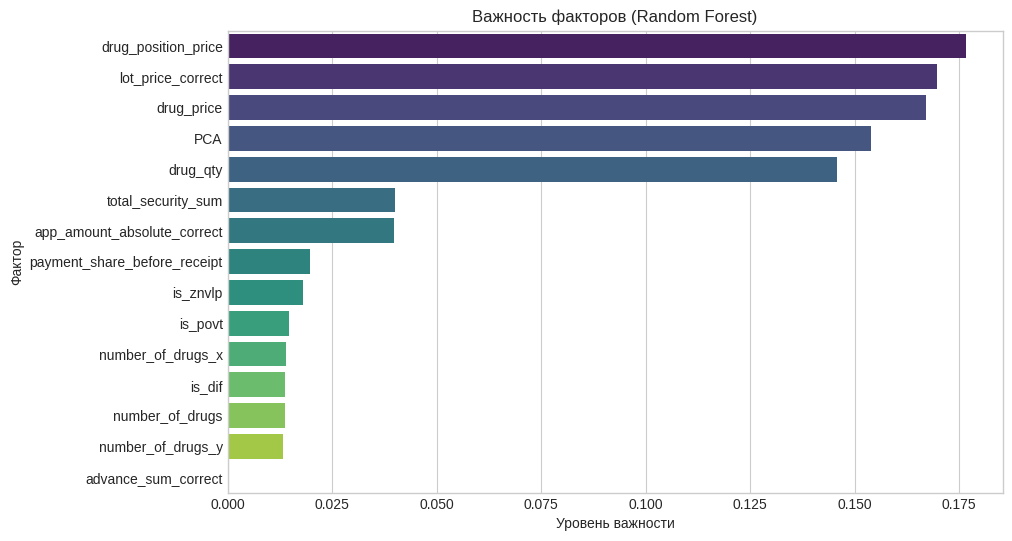

5 самых важных факторов: ['drug_position_price', 'lot_price_correct', 'drug_price', 'PCA', 'drug_qty']


In [46]:
# Оставляем только числовые данные
X_train_numeric = X_train.select_dtypes(include=[np.number])
X_test_numeric = X_test.select_dtypes(include=[np.number])

# Обучение модели Случайного Леса
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_final, y_train)

# Анализ важности признаков
df_importances = pd.DataFrame({
    'feature': X_train_numeric.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

# Визуализация
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=df_importances, palette='viridis', hue='feature', legend=False)
plt.title('Важность факторов (Random Forest)')
plt.xlabel('Уровень важности')
plt.ylabel('Фактор')
plt.show()

#  Вывод топ-5 факторов
top_factors = df_importances.head(5)['feature'].tolist()
print("5 самых важных факторов:", top_factors)

## Построение логистической регрессии


In [49]:
X_train = X_train[top_factors]
X_test = X_test[top_factors]

# Создание модели логистической регрессии и её обучение
logreg = LogisticRegression()
logreg.fit(X_train, y_train)

# Предсказание на обучающей и тестовой выборках
train_predictions = logreg.predict(X_train)
test_predictions = logreg.predict(X_test)

# Оценка точности на обучающей и тестовой выборках
train_accuracy = accuracy_score(y_train, train_predictions)
test_accuracy = accuracy_score(y_test, test_predictions)

# Вывод точности модели на обучающей и тестовой выборках
print("Точность модели на обучающей выборке:", train_accuracy)
print("Точность модели на тестовой выборке:", test_accuracy)

Точность модели на обучающей выборке: 0.5042351046698873
Точность модели на тестовой выборке: 0.5081159420289855


Точность около 0.5 означает, что модель правильно соотносит ~50% объектов.

Это практически случайное угадывание.
Таким образом, точность является низкой и указывает на то, что модель не может точно предсказывать целевую переменную.

Модель не пригодна для использования